In [1]:
import pandas as pd
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("merged_df_indoor.csv")

In [7]:
# Adding a new column with classifications
df['Binary'] = df['quality_mapped'].apply(lambda x: 1 if x >= 720 else 0)

In [36]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

In [38]:
X = df[['Level','Qual','SNR']]
y = df['Binary']

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [40]:
random_state_var = 42


Model: Logistic Regression
Classification Report:
               precision    recall  f1-score   support

         Low       0.61      0.51      0.56       519
        High       0.64      0.73      0.68       616

    accuracy                           0.63      1135
   macro avg       0.63      0.62      0.62      1135
weighted avg       0.63      0.63      0.62      1135



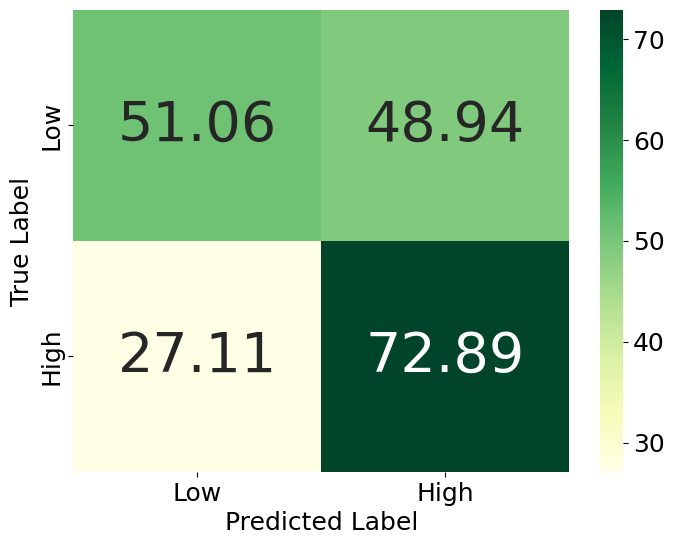

[[51.05973025 48.94026975]
 [27.11038961 72.88961039]]
Cross-validation scores (5 folds): [0.62075472 0.63018868 0.63962264 0.65595463 0.62570888]
Accuracies:  0.6344459107607804
Mean CV Accuracy: 0.6344459107607804
Test Accuracy: 0.6290748898678414

Model: Decision Tree
Classification Report:
               precision    recall  f1-score   support

         Low       0.74      0.77      0.75       519
        High       0.80      0.77      0.79       616

    accuracy                           0.77      1135
   macro avg       0.77      0.77      0.77      1135
weighted avg       0.77      0.77      0.77      1135



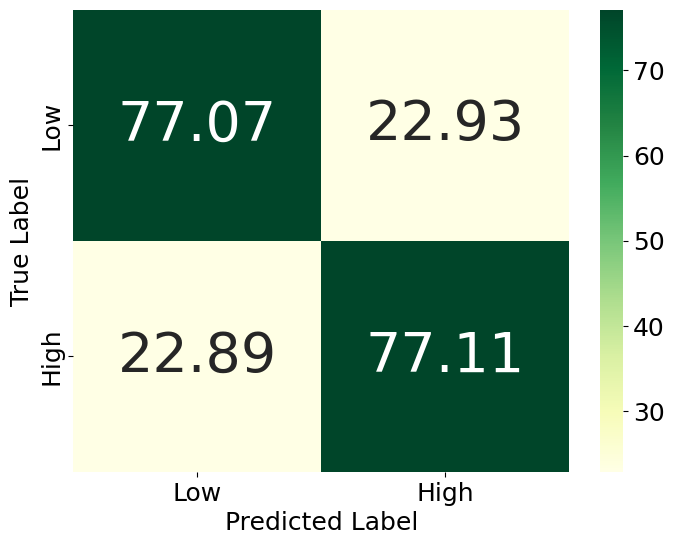

[[77.07129094 22.92870906]
 [22.88961039 77.11038961]]
Cross-validation scores (5 folds): [0.74716981 0.72830189 0.73207547 0.73724008 0.75803403]
Accuracies:  0.7405642543781431
Mean CV Accuracy: 0.7405642543781431
Test Accuracy: 0.7709251101321586

Model: Random Forest
Classification Report:
               precision    recall  f1-score   support

         Low       0.75      0.74      0.75       519
        High       0.78      0.80      0.79       616

    accuracy                           0.77      1135
   macro avg       0.77      0.77      0.77      1135
weighted avg       0.77      0.77      0.77      1135



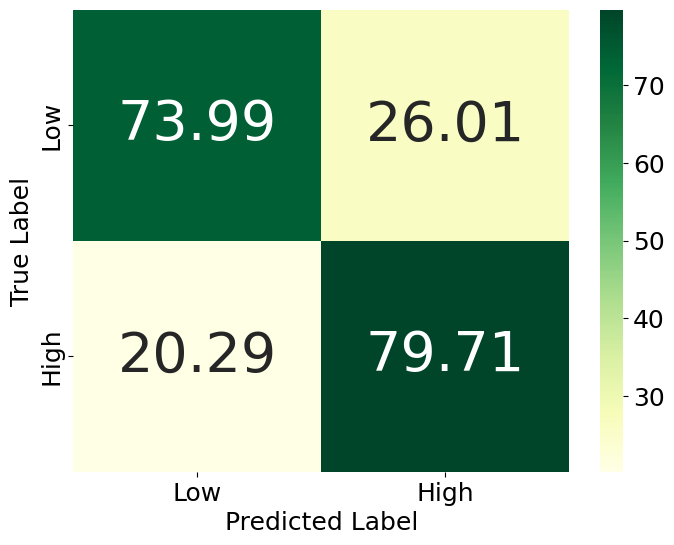

[[73.98843931 26.01156069]
 [20.29220779 79.70779221]]
Cross-validation scores (5 folds): [0.7509434  0.72830189 0.73396226 0.74480151 0.76937618]
Accuracies:  0.7454770481863252
Mean CV Accuracy: 0.7454770481863252
Test Accuracy: 0.7709251101321586

Model: Support Vector Machine (SVM)
Classification Report:
               precision    recall  f1-score   support

         Low       0.61      0.39      0.48       519
        High       0.60      0.79      0.68       616

    accuracy                           0.61      1135
   macro avg       0.61      0.59      0.58      1135
weighted avg       0.61      0.61      0.59      1135



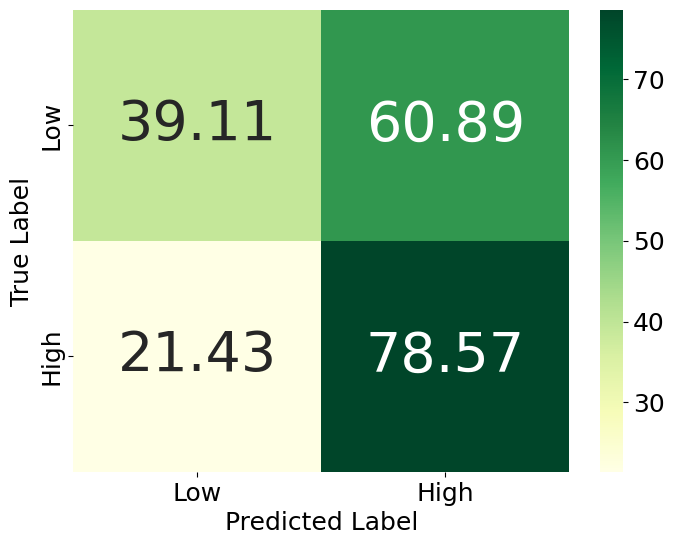

[[39.11368015 60.88631985]
 [21.42857143 78.57142857]]
Cross-validation scores (5 folds): [0.60943396 0.60188679 0.62075472 0.62192817 0.5973535 ]
Accuracies:  0.6102714270428362
Mean CV Accuracy: 0.6102714270428362
Test Accuracy: 0.6052863436123348


In [48]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state_var)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=random_state_var),
    "Decision Tree": DecisionTreeClassifier(random_state=random_state_var),
    "Random Forest": RandomForestClassifier(random_state=random_state_var),
    "Support Vector Machine (SVM)": SVC(probability=True,random_state=random_state_var)
}

# Train, predict, and evaluate each model
for name, model in models.items():
    print(f"\nModel: {name}")
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Print performance metrics
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Low','High']))
    
    # Confusion Matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
    # disp.plot(cmap=plt.cm.Blues)
    # plt.title(f"Confusion Matrix: {name}")
    # plt.show()

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # Convert counts to percentages
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    # Define class labels
    labels = label_encoder.classes_
    # Plot using seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn" , xticklabels=['Low','High'],yticklabels=['Low','High'],   annot_kws={"size": 40})
    # Titles and labels
    plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
    plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
    # plt.title("Confusion Matrix (Percentage)")
    plt.xlabel("Predicted Label", fontsize=18)
    plt.ylabel("True Label", fontsize=18)
    # Adjust the colorbar label size
    cbar = plt.gca().collections[0].colorbar  # Get colorbar
    cbar.ax.tick_params(labelsize=18)  # Increase colorbar font size

    plt.savefig("cmsstatic/"+str(name)+".pdf")
    # Show plot
    plt.show()
    print(cm_percentage)

    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print("Cross-validation scores (5 folds):", cv_scores)
    print("Accuracies: ", sum(cv_scores) / len(cv_scores))
    print("Mean CV Accuracy:", np.mean(cv_scores))
    print("Test Accuracy:", model.score(X_test, y_test))

In [52]:
# !pip install xgboost

Accuracy for each fold: [0.76037736 0.73396226 0.72830189 0.73534972 0.76748582]
Mean CV Accuracy: 0.7450954096372652
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75       519
           1       0.79      0.77      0.78       616

    accuracy                           0.77      1135
   macro avg       0.76      0.77      0.77      1135
weighted avg       0.77      0.77      0.77      1135



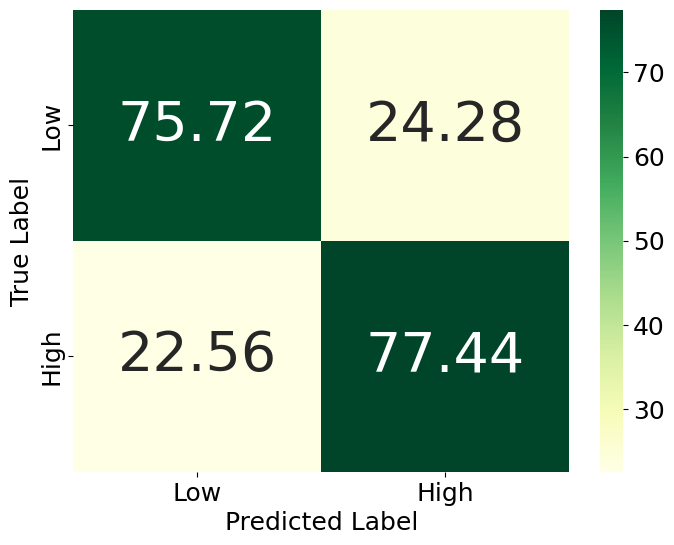

Test Score (Accuracy on test set): 0.7665


In [53]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# XGBoost model
xgb = XGBClassifier(eval_metric='logloss', random_state=random_state_var)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='accuracy')

# Print fold-wise accuracy
print("Accuracy for each fold:", cv_scores)

# Print mean accuracy
print("Mean CV Accuracy:", cv_scores.mean())

# Fit the model on the entire training data
xgb.fit(X_train, y_train)

# Calculate the accuracy on the test set
test_score = xgb.score(X_test, y_test)

# Predictions
y_pred = xgb.predict(X_test)

# Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix: XGBoost")
# plt.show()
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Define class labels
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn", xticklabels=['Low','High'],yticklabels=['Low','High'],   annot_kws={"size": 40})
# Titles and labels
plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
# plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
cbar = plt.gca().collections[0].colorbar  # Get colorbar
cbar.ax.tick_params(labelsize=18)
plt.savefig("cmsstatic/xgboost.pdf")
# Show plot
plt.show()
# print()

# Print test score (accuracy on test set)
print(f"Test Score (Accuracy on test set): {test_score:.4f}")

Accuracy for each fold: [0.7509434  0.73018868 0.73018868 0.72022684 0.74102079]
Mean CV Accuracy: 0.7345136783536041
Test Accuracy: 0.7612
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.77      0.75       519
           1       0.80      0.75      0.77       616

    accuracy                           0.76      1135
   macro avg       0.76      0.76      0.76      1135
weighted avg       0.76      0.76      0.76      1135



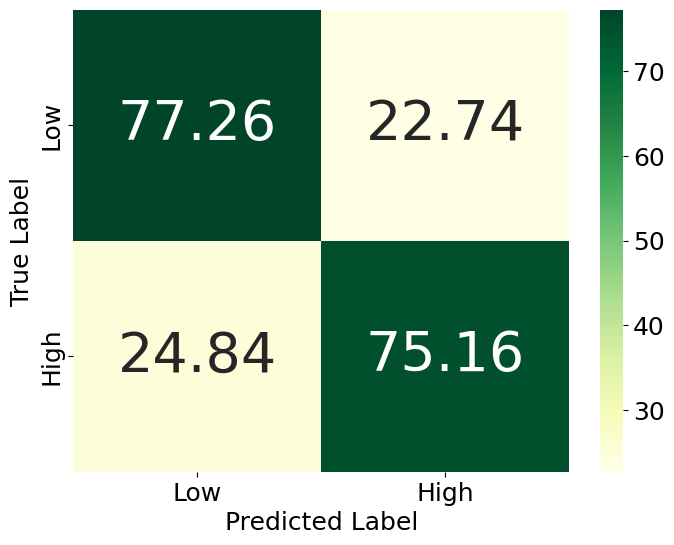

In [54]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define base models
base_models = [
    ('lr', LogisticRegression(random_state=random_state_var)),
    ('dt', DecisionTreeClassifier(random_state=random_state_var)),
    ('svc', SVC(probability=True,random_state=random_state_var)),
    ('xgb', XGBClassifier(eval_metric='logloss',random_state=random_state_var)),  # Add XGBoost as a base model
    ('rf', RandomForestClassifier(random_state=random_state_var))  # Add Random Forest as a base model
]

# Define the final meta-model (Random Forest)
stack_model = StackingClassifier(estimators=base_models, final_estimator=RandomForestClassifier())

# 5-Fold Cross-Validation
cv_scores = cross_val_score(stack_model, X_train, y_train, cv=5, scoring='accuracy')

# Print fold-wise accuracy and mean accuracy
print("Accuracy for each fold:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# Fit the model on the entire training set
stack_model.fit(X_train, y_train)

# Test Accuracy
test_accuracy = stack_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions
y_pred = stack_model.predict(X_test)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix: StackingClassifier")
# plt.show()
cm = confusion_matrix(y_test, y_pred)
# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Define class labels
labels = label_encoder.classes_
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn", xticklabels=['Low','High'],yticklabels=['Low','High'],  annot_kws={"size": 40})
# Titles and labels
plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
# plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
# Adjust the colorbar label size
cbar = plt.gca().collections[0].colorbar  # Get colorbar
cbar.ax.tick_params(labelsize=18)  # Increase colorbar font size

plt.savefig("cmsstatic/stacking.pdf")
# Show plot
plt.show()

Accuracy for each fold: [0.75849057 0.72075472 0.73773585 0.72967864 0.75425331]
Mean CV Accuracy: 0.740182615829083
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74       519
           1       0.78      0.80      0.79       616

    accuracy                           0.77      1135
   macro avg       0.77      0.77      0.77      1135
weighted avg       0.77      0.77      0.77      1135



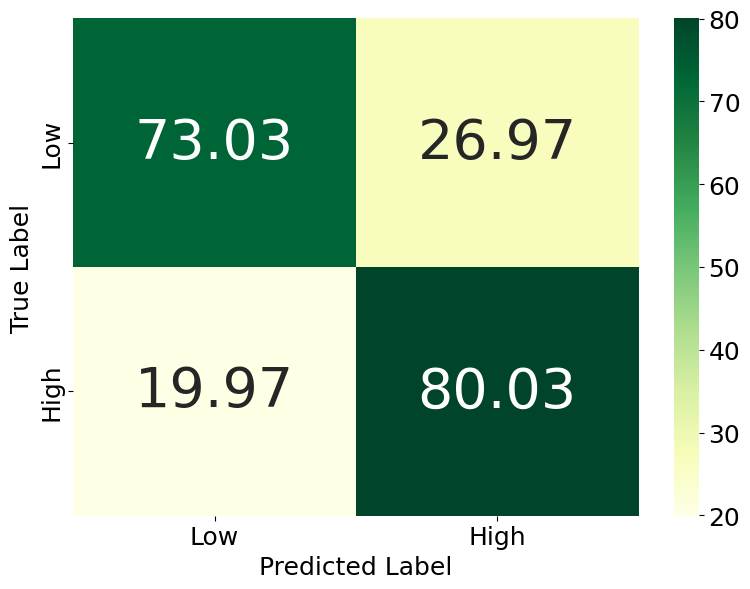

Test Score (Accuracy on test set): 0.7683


In [55]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Define base models
lr = LogisticRegression(random_state=random_state_var)
dt = DecisionTreeClassifier(random_state=random_state_var)
svc = SVC(probability=True,random_state=random_state_var)
xgb = XGBClassifier(eval_metric='logloss',random_state=random_state_var)
rf = RandomForestClassifier(random_state=random_state_var)

# Define Voting Classifier (Soft Voting)
voting_model = VotingClassifier(estimators=[
    ('lr', lr),
    ('dt', dt),
    ('svc', svc),
    ('xgb', xgb),
    ('rf', rf)
], voting='soft')

# Perform 5-fold cross-validation
cv_scores = cross_val_score(voting_model, X_train, y_train, cv=5, scoring='accuracy')

# Print fold-wise accuracy
print("Accuracy for each fold:", cv_scores)

# Print mean accuracy across all folds
print("Mean CV Accuracy:", cv_scores.mean())

# Fit the model on the entire training data (for test set evaluation)
voting_model.fit(X_train, y_train)

# Calculate accuracy on the test set
test_score = voting_model.score(X_test, y_test)

# Predictions on test set
y_pred = voting_model.predict(X_test)

# Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix: Voting Classifier")
# plt.show()
cm = confusion_matrix(y_test, y_pred)
# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Define class labels
labels = label_encoder.classes_
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn",  xticklabels=['Low','High'],yticklabels=['Low','High'],   annot_kws={"size": 40})
# Titles and labels
plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
# plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
# Adjust the colorbar label size
cbar = plt.gca().collections[0].colorbar  # Get colorbar
cbar.ax.tick_params(labelsize=18)  # Increase colorbar font size

plt.savefig("cmsstatic/vooting.pdf")
plt.tight_layout()
# Show plot
plt.show()
# Print test score (accuracy on test set)
print(f"Test Score (Accuracy on test set): {test_score:.4f}")
